## Sleep Health & lifestyle

In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [128]:
data = pd.read_csv(r"D:\ME\data analsis\projects\project 9 (sleep)\dataset\Sleep_health_and_lifestyle_dataset.csv")
data

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [129]:
df = data.copy()

#### Data Understanding

In [130]:
df.shape

(374, 13)

In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [132]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


#### data cleaning

In [133]:
df.isna().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

Sleep Disorder --> 219 null

In [134]:
df['Sleep Disorder'].value_counts()

Sleep Disorder
Sleep Apnea    78
Insomnia       77
Name: count, dtype: int64

In [135]:
df.duplicated().sum()

np.int64(0)

In [136]:
df['Physical Activity Level']

0      42
1      60
2      60
3      30
4      30
       ..
369    75
370    75
371    75
372    75
373    75
Name: Physical Activity Level, Length: 374, dtype: int64

In [137]:
df['Physical Activity Level'] = df['Physical Activity Level'] /10
df['Physical Activity Level']

0      4.2
1      6.0
2      6.0
3      3.0
4      3.0
      ... 
369    7.5
370    7.5
371    7.5
372    7.5
373    7.5
Name: Physical Activity Level, Length: 374, dtype: float64

## EDA

In [138]:
df['Gender'].value_counts()

Gender
Male      189
Female    185
Name: count, dtype: int64

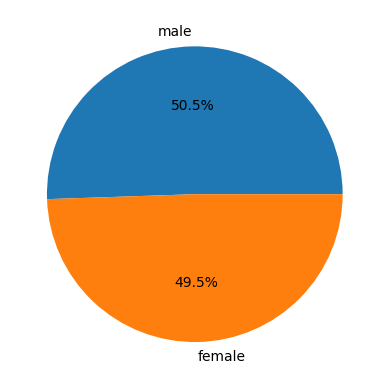

In [139]:
count_of_genders = df['Gender'].value_counts()
plt.pie(
    count_of_genders,
    labels=['male','female'],
    autopct='%1.01f%%'
)
plt.axis =['equal']


In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    float64
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(2), int64(6), object(5)
memory usage: 38.1+ KB


In [141]:
## Occupation
## هل المجال الي بشتغل فيه بيأثر ع النوم ؟؟؟
df['Occupation'].value_counts()

Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Scientist                4
Software Engineer        4
Sales Representative     2
Manager                  1
Name: count, dtype: int64

In [142]:
occupation_cat = {
    'Nurse':'Medical',
    'Doctor':'Medical',
    'Engineer':'Technical',
    'Lawyer':'Legal',
    'Teacher':'Education',
    'Accountant':'Finance',
    'Salesperson':'Sales',
    'Scientist':'Technical',
    'Software Engineer':'Technical',
    'Sales Representative':'Sales',
    'Manager':'Management',
    
}

In [143]:
df['Occupation category'] = df['Occupation'].map(occupation_cat)

In [144]:
df['Occupation category'].value_counts()

Occupation category
Medical       144
Technical      71
Legal          47
Education      40
Finance        37
Sales          34
Management      1
Name: count, dtype: int64

<BarContainer object of 374 artists>

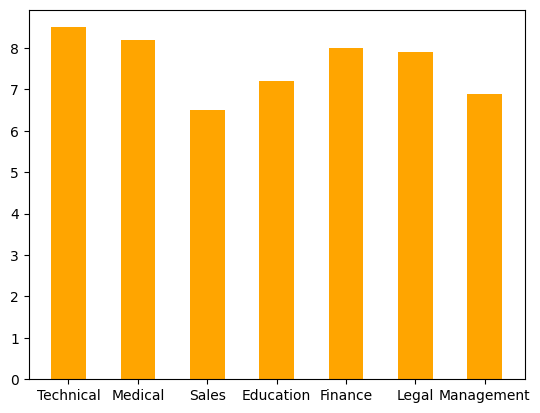

In [145]:
plt.bar(
    df['Occupation category'] , df['Sleep Duration'],
    color = 'orange',
    width = 0.5,
    
)

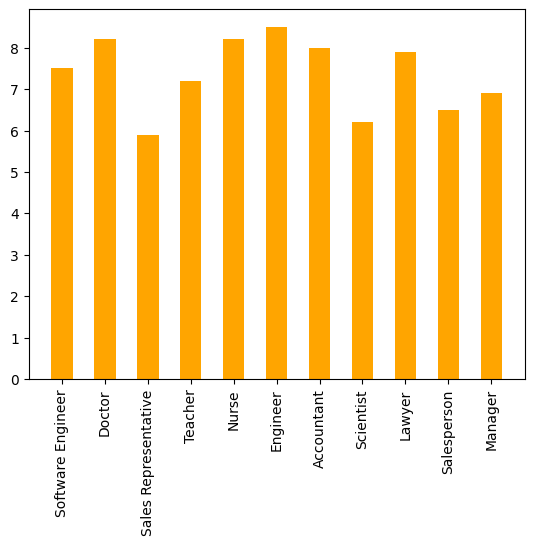

In [146]:
plt.bar(
    df['Occupation'] , df['Sleep Duration'],
    color = 'orange',
    width = 0.5,
    
)
plt.xticks(rotation=90)
plt.axis = ['eqal']


(25.0, 60.0)

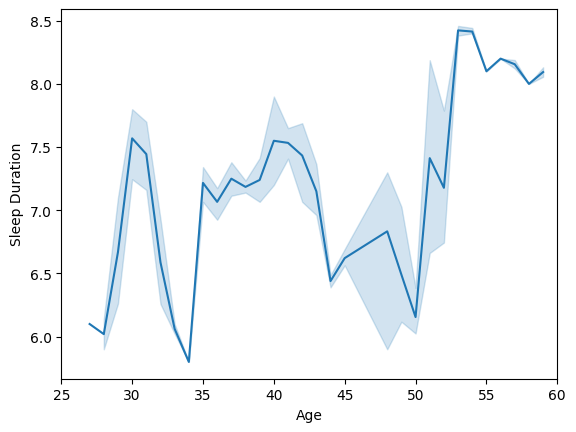

In [147]:
## Age
## هل مع كبر السن او ف المراحل العمري ةالمختلفة  عدد ساعات النوم بيتأثر ؟؟؟
sns.lineplot(
    data=df,
    x='Age',
    y='Sleep Duration',
    estimator='mean'
)
plt.xlim(25, 60)


In [148]:
df.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder', 'Occupation category'],
      dtype='object')

In [149]:
## Sleep quilty
## هل عدد الساعات الكتير ف النوم بيكون هدفه نوم احسن 
df.groupby('Quality of Sleep')['Sleep Duration'].mean()

Quality of Sleep
4    5.860000
5    6.500000
6    6.195238
7    7.140260
8    7.403670
9    8.243662
Name: Sleep Duration, dtype: float64

<Axes: xlabel='Quality of Sleep', ylabel='Sleep Duration'>

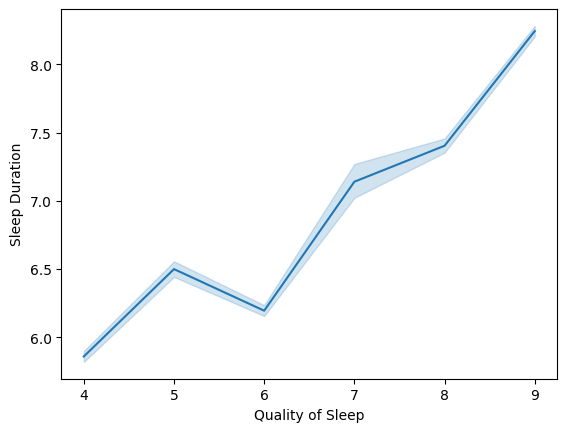

In [150]:
sns.lineplot(
    data=df,
    x='Quality of Sleep',
    y='Sleep Duration',
    estimator='mean'
)


(3.5, 10.0)

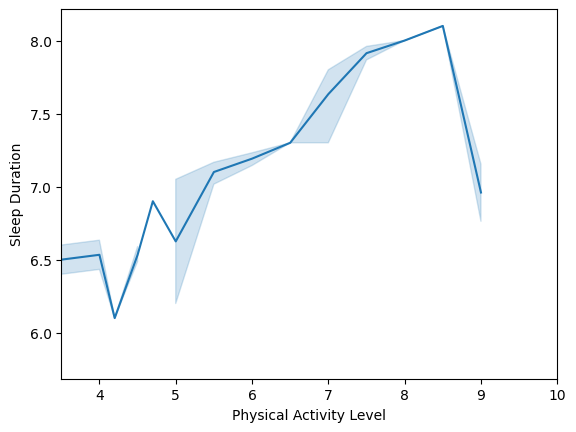

In [151]:
## Physical Activity Level
sns.lineplot(
    data=df,
    x='Physical Activity Level',
    y='Sleep Duration',
    estimator='mean'
)
plt.xlim(3.5, 10)



In [152]:
bins = [5,6,7,8.5]
labels = ['Low' , 'Medium' , 'High']
df['Sleep category'] = pd.cut(
    df['Sleep Duration'],
    bins = bins ,
    labels= labels ,
    include_lowest=True
)
df['Sleep category']

0      Medium
1      Medium
2      Medium
3         Low
4         Low
        ...  
369      High
370      High
371      High
372      High
373      High
Name: Sleep category, Length: 374, dtype: category
Categories (3, object): ['Low' < 'Medium' < 'High']

<Axes: xlabel='Stress Level', ylabel='Sleep category'>

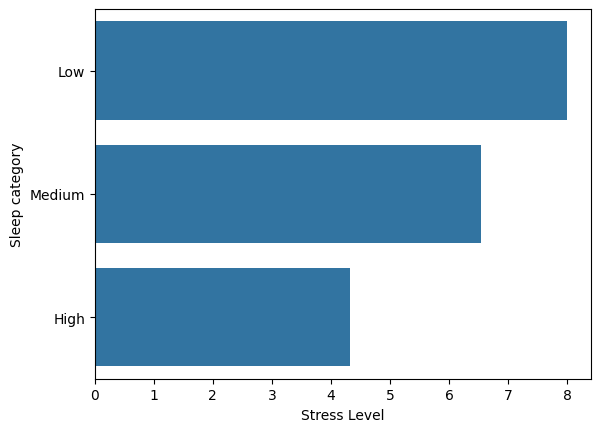

In [153]:
sns.barplot(
    data=df,
    x='Stress Level',
    y='Sleep category',
    errorbar=None
)

In [154]:
bins = [0, 3, 6, 10]
labels = ['Low', 'Medium', 'High']

df['Stress_Category'] = pd.cut(
    df['Stress Level'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

<Axes: xlabel='Stress_Category', ylabel='Sleep Duration'>

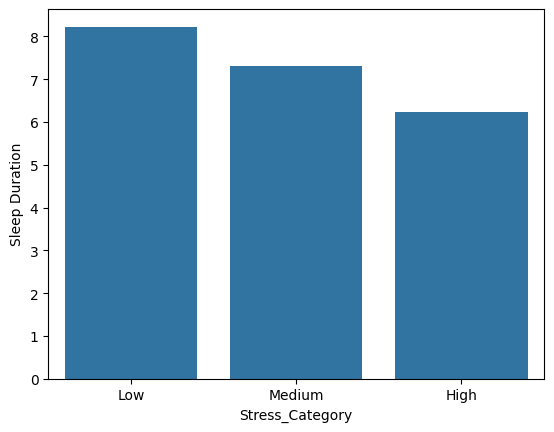

In [155]:
sns.barplot(
    data=df,
    x='Stress_Category',
    y='Sleep Duration',
    errorbar=None
)

<Axes: xlabel='Stress_Category', ylabel='Sleep Duration'>

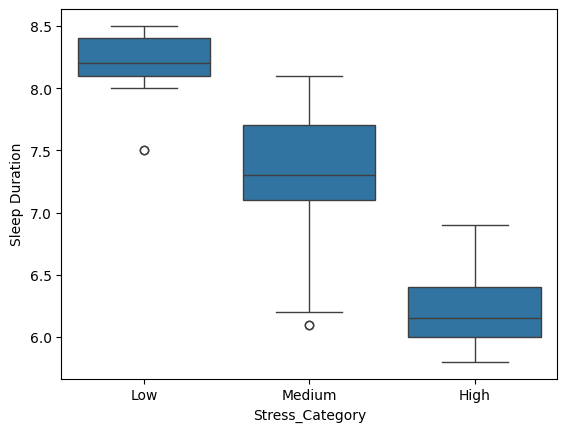

In [156]:
sns.boxplot(
    data=df,
    x='Stress_Category',
    y='Sleep Duration',
)

<Axes: xlabel='BMI Category', ylabel='count'>

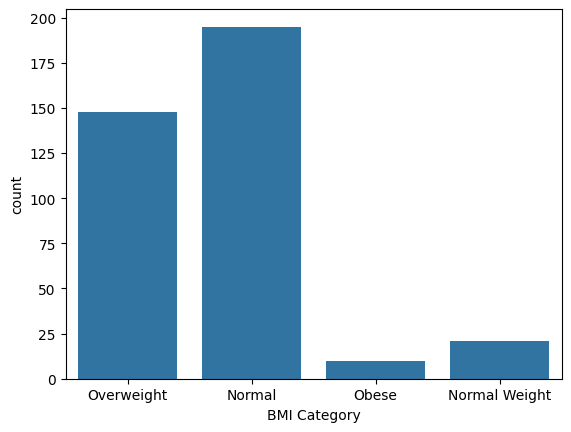

In [157]:
sns.countplot(data=df, x='BMI Category')

In [158]:
df['Sleep Disorder'].fillna('Normal Sleep' , inplace=True)

df['Sleep Disorder']

C:\Users\Mahmoud shaban\AppData\Local\Temp\ipykernel_25920\614430697.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Sleep Disorder'].fillna('Normal Sleep' , inplace=True)


0      Normal Sleep
1      Normal Sleep
2      Normal Sleep
3       Sleep Apnea
4       Sleep Apnea
           ...     
369     Sleep Apnea
370     Sleep Apnea
371     Sleep Apnea
372     Sleep Apnea
373     Sleep Apnea
Name: Sleep Disorder, Length: 374, dtype: object

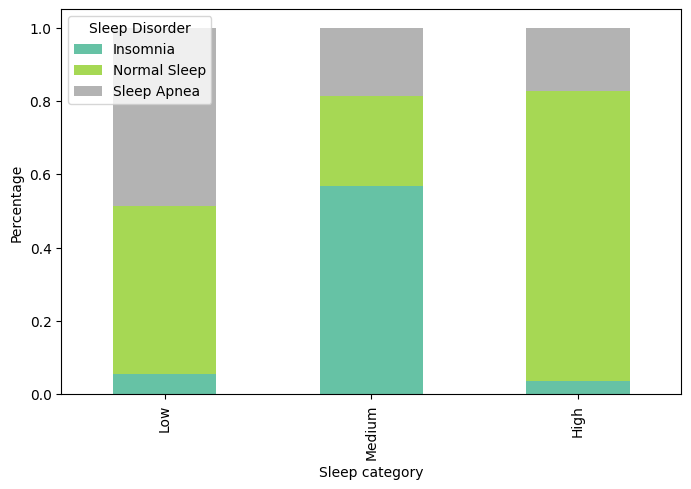

In [159]:
pd.crosstab(
    df['Sleep category'],
    df['Sleep Disorder'],
    normalize='index'
).plot(
    kind='bar',
    stacked=True,
    figsize=(8,5),
    colormap='Set2'
)

plt.ylabel('Percentage')
plt.show()

In [160]:
bins = [3000, 5000, 7000, 10000]
labels = ['Low activity', 'Medium activity', 'High activity']

df['Steps Category'] = pd.cut(
    df['Daily Steps'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

<Axes: xlabel='Steps Category', ylabel='Sleep Duration'>

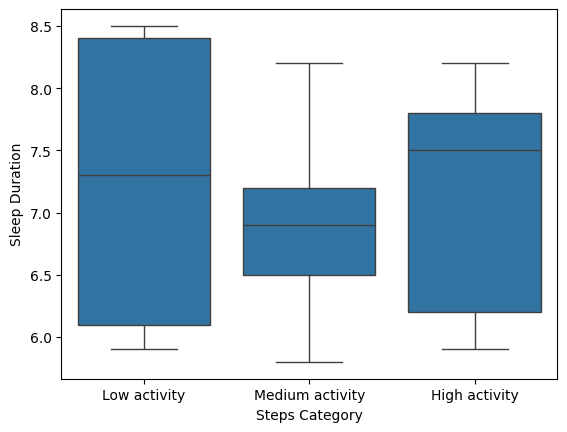

In [161]:
sns.boxplot(
    data=df,
    x='Steps Category',
    y='Sleep Duration'
)

<Axes: >

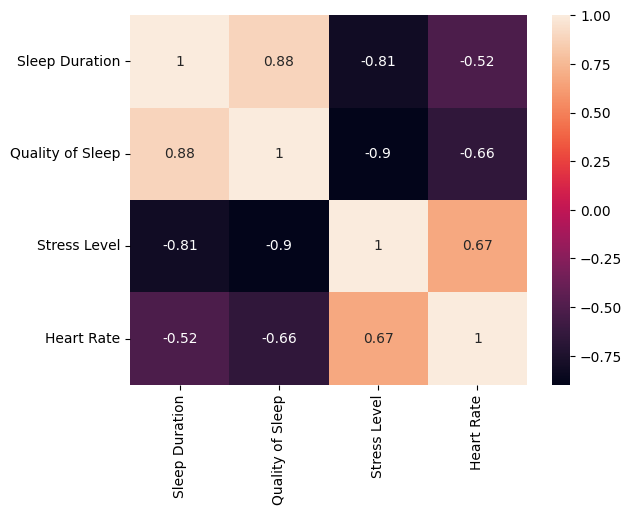

In [163]:
columns = [
    'Sleep Duration','Quality of Sleep','Stress Level','Heart Rate'
]

sns.heatmap(
    df[columns].corr(),
    annot=True,
)

In [164]:
df.to_csv('clean_data.csv' , index=False)